In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [93]:
file_path = r"C:\Projects\SPD-Track-Parameter-Prediction\data\processed\output.tsv"

df_1 = pd.read_csv(file_path, sep="\t")

In [94]:
df_1["track_id"].unique()

array([ 0,  1,  2,  3,  4,  5, -1,  6,  7,  8])

In [95]:
signal_df = df_1[df_1["track_id"] >= 0]
print(signal_df)

         event_id           x           y           z  station  track_id  \
0               0 -243.654645 -116.136668  174.344223        1         0   
1               0 -258.599490 -124.355011  196.391469        2         0   
2               0 -273.680339 -132.583800  218.517131        3         0   
3               0 -288.458646 -141.034465  240.751036        4         0   
4               0 -303.503860 -149.429092  262.849730        5         0   
...           ...         ...         ...         ...      ...       ...   
1126722      4999  403.419099 -669.635127  543.483363       31         1   
1126723      4999  409.739601 -685.755734  560.698008       32         1   
1126724      4999  415.893523 -702.023553  578.165324       33         1   
1126725      4999  422.108770 -718.051864  595.366103       34         1   
1126726      4999  428.056716 -734.395730  612.859140       35         1   

                 px          py          pz   vertex_x   vertex_y    vertex_z  \
0     

In [96]:
print(signal_df["track_id"].unique()[:20])

[0 1 2 3 4 5 6 7 8]


In [97]:
signal_df.to_csv(
    r"C:\Projects\SPD-Track-Parameter-Prediction\data\processed\signal_hits.tsv",
    sep="\t",
    index=False
)

In [99]:
df = pd.read_csv(r"C:\Projects\SPD-Track-Parameter-Prediction\data\processed\signal_hits.tsv", sep="\t")

In [100]:
df.head()

,event_id,x,y,z,station,track_id,px,py,pz,vertex_x,vertex_y,vertex_z,pt,phi,theta,charge
0,0,-243.654645,-116.136668,174.344223,1,0,-523.052938,-283.768220,773.380967,-23.817434,-17.20341,-176.948134,595.070398,3.533347,2.485765,-1
1,0,-258.599490,-124.355011,196.391469,2,0,-521.151301,-287.245713,773.380967,-23.817434,-17.20341,-176.948134,595.070398,3.533347,2.485765,-1
2,0,-273.680339,-132.583800,218.517131,3,0,-519.226184,-290.711109,773.380967,-23.817434,-17.20341,-176.948134,595.070398,3.533347,2.485765,-1
3,0,-288.458646,-141.034465,240.751036,4,0,-517.277636,-294.164284,773.380967,-23.817434,-17.20341,-176.948134,595.070398,3.533347,2.485765,-1
4,0,-303.503860,-149.429092,262.849730,5,0,-515.305708,-297.605117,773.380967,-23.817434,-17.20341,-176.948134,595.070398,3.533347,2.485765,-1


In [101]:
df.describe()

,event_id,x,y,z,station,track_id,px,py,pz,vertex_x,vertex_y,vertex_z,pt,phi,theta,charge
count,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000,853413.000000
mean,2502.448435,4.721830,1.329582,4.162240,17.822612,2.686382,2.022924,1.035575,-1.505783,0.070569,-0.095614,3.587196,549.272049,3.149764,1.566599,0.001098
std,1441.026474,413.823483,410.565883,642.400528,10.088529,2.214622,432.199131,426.840632,690.946444,9.893636,9.979581,173.697123,259.410952,1.825626,0.651077,1.000000
min,0.000000,-850.241178,-850.187032,-2386.011113,1.000000,0.000000,-998.643125,-999.508720,-7755.577264,-35.559546,-36.222759,-299.964948,100.027543,0.000665,0.108175,-1.000000
25%,1259.000000,-331.997970,-330.656453,-327.670150,9.000000,1.000000,-299.625162,-293.049015,-256.497252,-6.573224,-6.596171,-147.666376,325.286191,1.567460,1.060858,-1.000000
50%,2499.000000,10.098872,0.626030,5.161140,18.000000,2.000000,5.894491,-0.176868,1.430526,0.051970,-0.086630,7.060681,550.548302,3.129715,1.559520,1.000000
75%,3749.000000,339.029902,333.649491,333.919873,27.000000,4.000000,302.310133,295.439165,257.311756,6.732998,6.757040,155.920691,773.436052,4.746521,2.071438,1.000000
max,4999.000000,850.286793,850.280287,2385.797616,35.000000,8.000000,998.593568,999.865492,8888.347334,36.528889,38.173183,299.970276,999.996485,6.283118,3.037666,1.000000


In [102]:
len(df)

853413

In [103]:
df["radius"] = np.sqrt(
    df["x"]**2 +
    df["y"]**2
)
print(df["radius"].describe())

count    853413.000000
mean        556.974013
std         172.098424
min         269.553574
25%         406.477155
50%         559.959935
75%         713.388790
max         850.357682
Name: radius, dtype: float64


In [104]:
df["event_id"].unique()

array([   0,    1,    2, ..., 4997, 4998, 4999], shape=(4995,))

In [105]:
print(df.columns)

Index(['event_id', 'x', 'y', 'z', 'station', 'track_id', 'px', 'py', 'pz',
       'vertex_x', 'vertex_y', 'vertex_z', 'pt', 'phi', 'theta', 'charge',
       'radius'],
      dtype='object')


In [106]:
print(df["track_id"].nunique())

9


In [107]:
print(df["track_id"].head())
print(df["track_id"].dtype)
print(df["track_id"].unique()[:20])

0    0
1    0
2    0
3    0
4    0
Name: track_id, dtype: int64
int64
[0 1 2 3 4 5 6 7 8]


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853413 entries, 0 to 853412
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   event_id  853413 non-null  int64  
 1   x         853413 non-null  float64
 2   y         853413 non-null  float64
 3   z         853413 non-null  float64
 4   station   853413 non-null  int64  
 5   track_id  853413 non-null  int64  
 6   px        853413 non-null  float64
 7   py        853413 non-null  float64
 8   pz        853413 non-null  float64
 9   vertex_x  853413 non-null  float64
 10  vertex_y  853413 non-null  float64
 11  vertex_z  853413 non-null  float64
 12  pt        853413 non-null  float64
 13  phi       853413 non-null  float64
 14  theta     853413 non-null  float64
 15  charge    853413 non-null  int64  
 16  radius    853413 non-null  float64
dtypes: float64(13), int64(4)
memory usage: 110.7 MB


In [109]:
df.isnull().sum()

event_id    0
x           0
y           0
z           0
station     0
track_id    0
px          0
py          0
pz          0
vertex_x    0
vertex_y    0
vertex_z    0
pt          0
phi         0
theta       0
charge      0
radius      0
dtype: int64

In [110]:
df["event_id"].value_counts()

event_id
2607    315
4943    315
4904    315
4956    315
59      315
       ... 
4709      8
2674      6
972       5
18        3
2615      1
Name: count, Length: 4995, dtype: int64

In [111]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
853408    False
853409    False
853410    False
853411    False
853412    False
Length: 853413, dtype: bool

In [112]:
per_evt_hits = df.groupby("event_id").size() # no. of hits per event 
per_evt_hits

event_id
0       210
1        70
2       245
3       140
4        70
       ... 
4995    245
4996    105
4997    140
4998    159
4999     46
Length: 4995, dtype: int64

In [113]:
per_trk_hits = df.groupby("track_id").size() # no. of hits per track 
per_trk_hits

track_id
0    168904
1    150999
2    131904
3    113461
4     94816
5     77507
6     58429
7     39114
8     18279
dtype: int64

In [114]:
df["station"].value_counts().sort_index()  # minor inconsistency in no. of hits per station 

station
1     24984
2     24964
3     24944
4     24926
5     24900
6     24865
7     24840
8     24812
9     24784
10    24758
11    24718
12    24674
13    24649
14    24616
15    24579
16    24533
17    24492
18    24444
19    24397
20    24350
21    24298
22    24247
23    24201
24    24159
25    24105
26    24055
27    24005
28    23946
29    23889
30    23838
31    23788
32    23746
33    23699
34    23637
35    23571
Name: count, dtype: int64

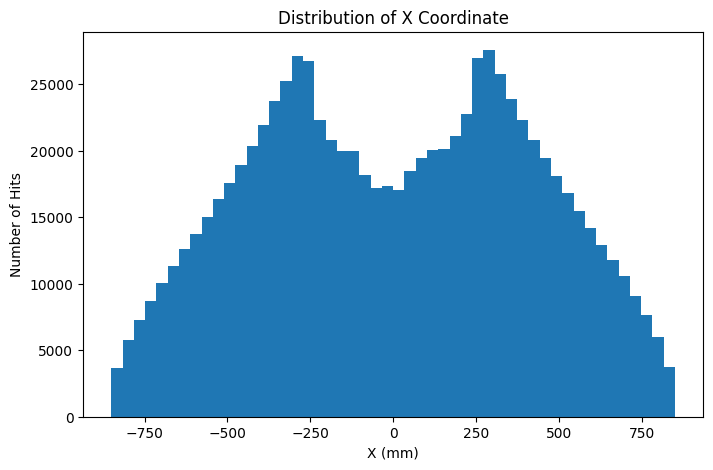

In [115]:
# hits distribution on x coordinate
plt.figure(figsize=(8,5))

plt.hist(df["x"], bins=50)

plt.title("Distribution of X Coordinate")
plt.xlabel("X (mm)")
plt.ylabel("Number of Hits")

plt.show()

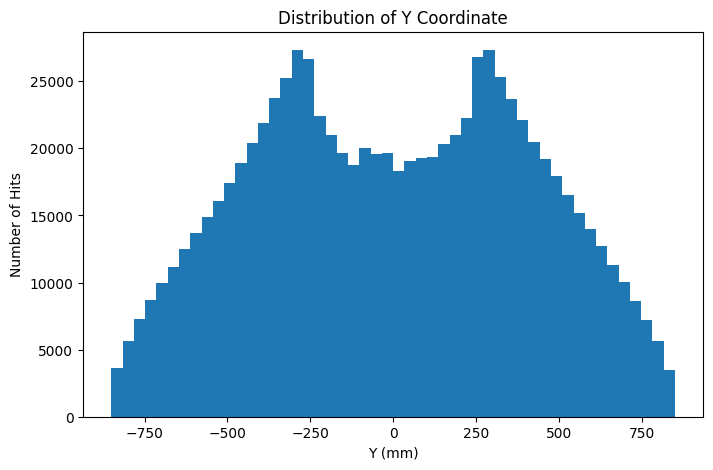

In [116]:
# hits distribution on y coordinate
plt.figure(figsize=(8,5))

plt.hist(df["y"], bins=50)

plt.title("Distribution of Y Coordinate")
plt.xlabel("Y (mm)")
plt.ylabel("Number of Hits")

plt.show()

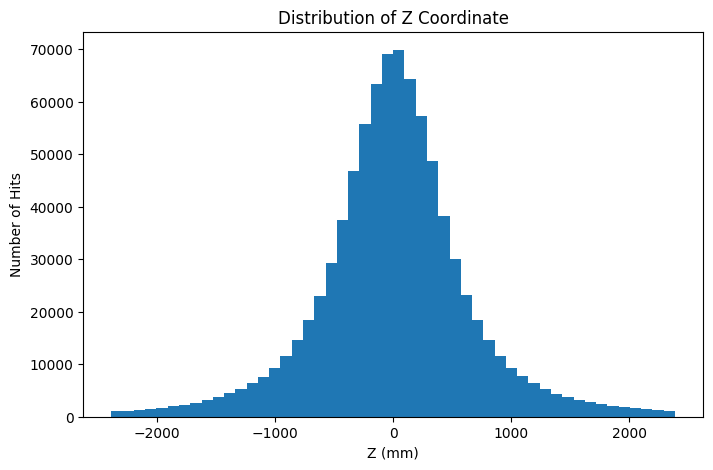

In [117]:
# hits distribution on z coordinate
plt.figure(figsize=(8,5))

plt.hist(df["z"], bins=50)

plt.title("Distribution of Z Coordinate")
plt.xlabel("Z (mm)")
plt.ylabel("Number of Hits")

plt.show()

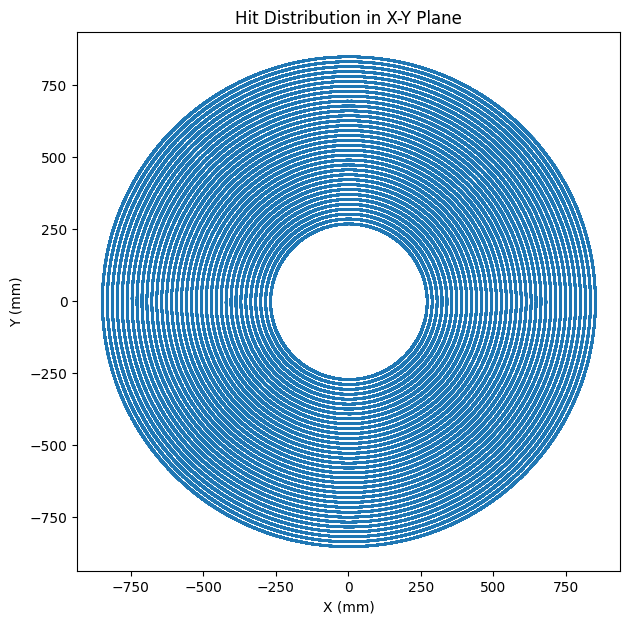

In [118]:
plt.figure(figsize=(7,7))

plt.scatter(df["x"], df["y"], s=1)

plt.title("Hit Distribution in X-Y Plane")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")

plt.show()

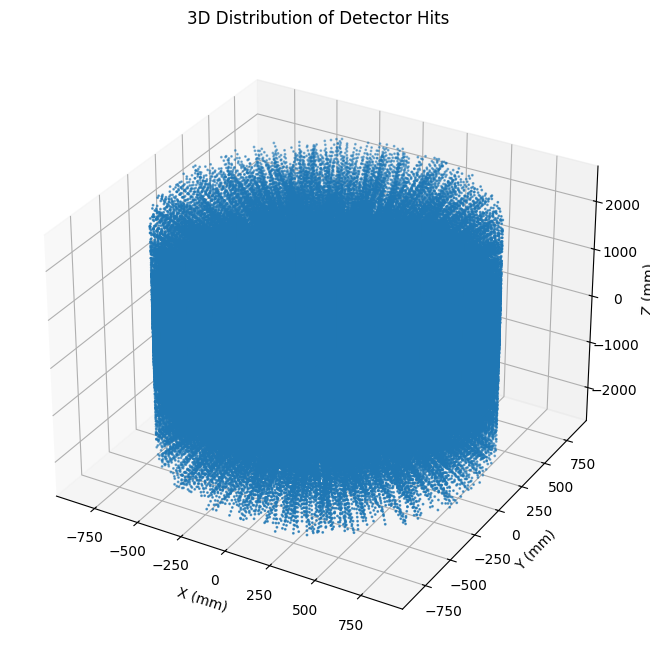

In [119]:
# 3D plot to visualize hits on x y z coord
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["x"],
    df["y"],
    df["z"],
    s=1
)

ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.set_title("3D Distribution of Detector Hits")

plt.show()

In [120]:
# calculate distance of hits from center of detector
df["radius"] = np.sqrt(df["x"]**2 + df["y"]**2)
print(df[["x", "y", "radius"]].head())

            x           y      radius
0 -243.654645 -116.136668  269.917231
1 -258.599490 -124.355011  286.945753
2 -273.680339 -132.583800  304.104245
3 -288.458646 -141.034465  321.090502
4 -303.503860 -149.429092  338.295206


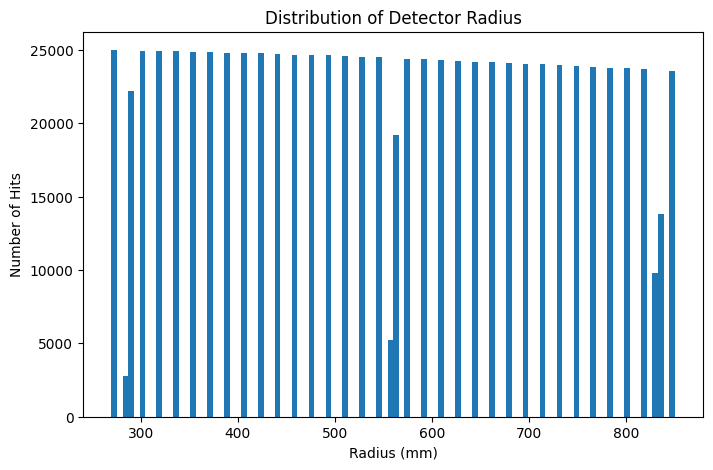

In [ ]:
df["radius"] = np.sqrt(df["x"]**2 + df["y"]**2)

plt.figure(figsize=(8,5))
plt.hist(df["radius"], bins=100)
plt.xlabel(" Radius (mm)")
plt.ylabel("Number of Hits ")
plt.title(" Distribution of Detector Radius")
plt.show()

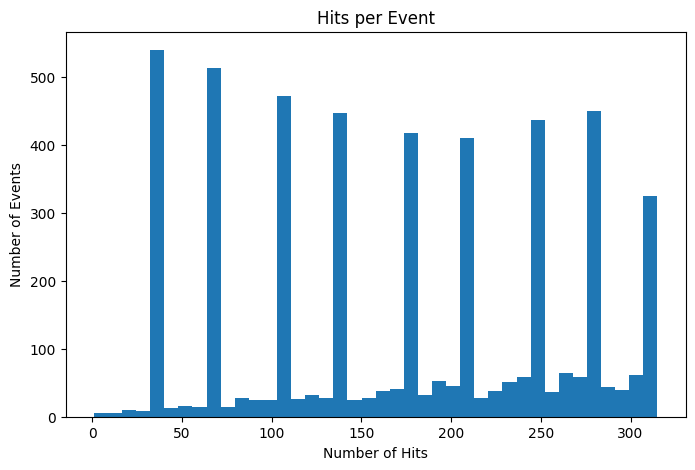

In [122]:
# hits per event 
hits_per_event = df.groupby("event_id").size()

plt.figure(figsize=(8,5))
plt.hist(hits_per_event, bins=40)

plt.title("Hits per Event")
plt.xlabel("Number of Hits")
plt.ylabel("Number of Events")

plt.show()



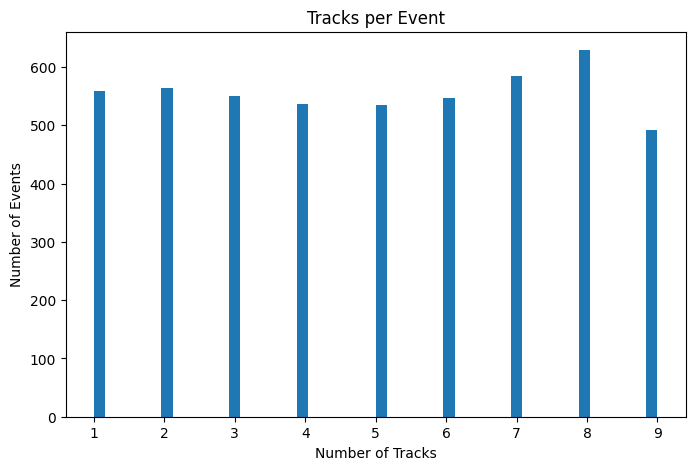

In [123]:
# tracks per event 
tracks_per_event = df.groupby("event_id")["track_id"].nunique()

plt.figure(figsize=(8,5))
plt.hist(tracks_per_event, bins=50)

plt.title("Tracks per Event")
plt.xlabel("Number of Tracks")
plt.ylabel("Number of Events")

plt.show()

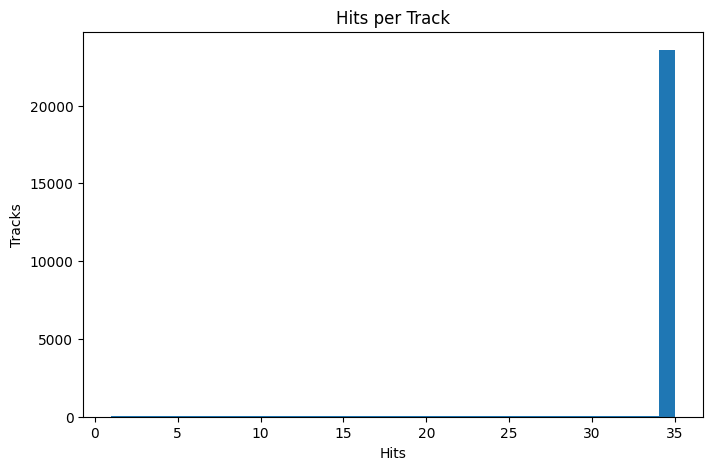

In [132]:
hits_per_track = df.groupby(["event_id","track_id"]).size()

plt.figure(figsize=(8,5))
plt.hist(hits_per_track, bins=35)

plt.title("Hits per Track")
plt.xlabel("Hits")
plt.ylabel("Tracks")

plt.show()

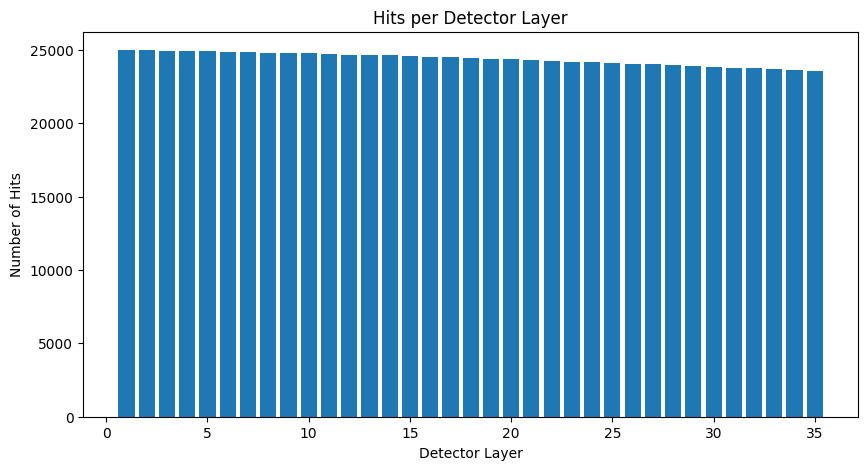

In [ ]:
layer_hits = df["station"].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.bar(layer_hits.index, layer_hits.values)

plt.xlabel("Detector Layer")
plt.ylabel(" Number of Hits")
plt.title("Hits per Detector Layer")

plt.show()

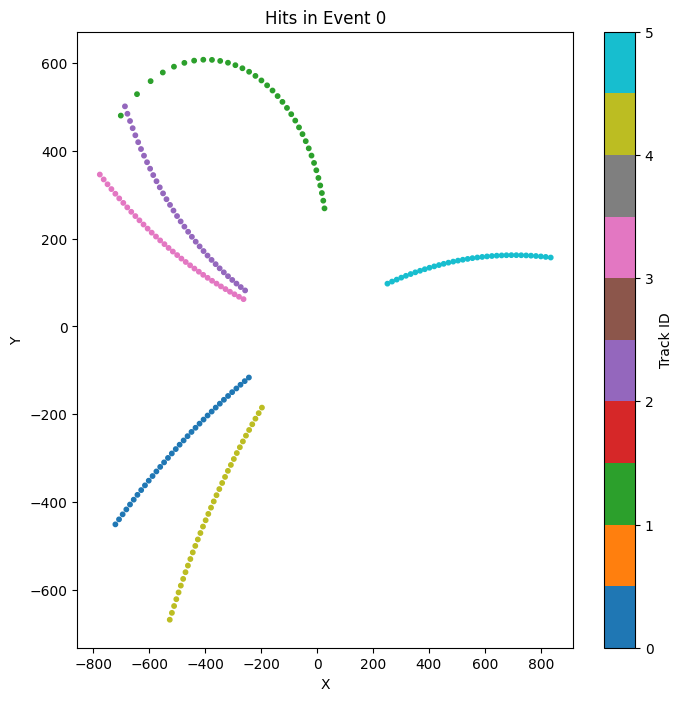

In [134]:
event = df[df["event_id"] == 0]

plt.figure(figsize=(8,8))

plt.scatter(
    event["x"],
    event["y"],
    c=event["track_id"],
    s=10,
    cmap="tab10"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Hits in Event 0")

plt.colorbar(label="Track ID")

plt.show()

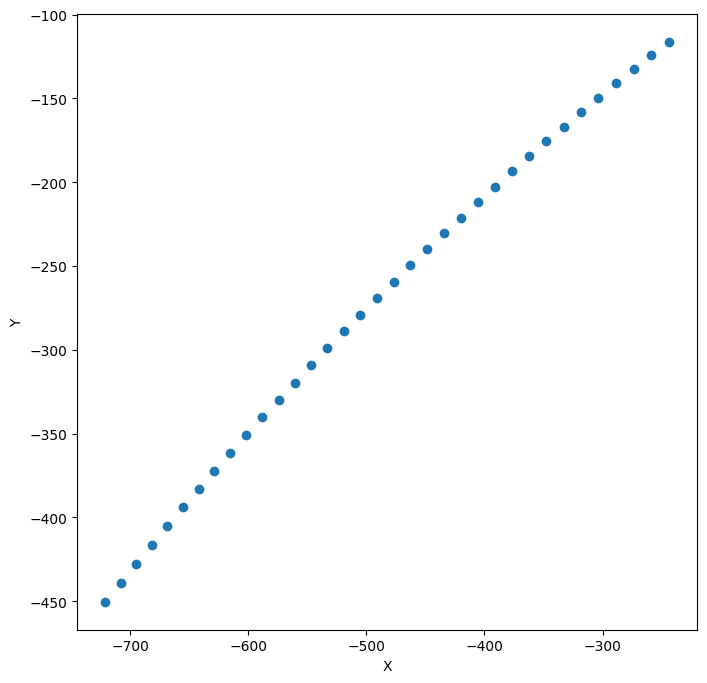

In [135]:
track = df[
    (df["event_id"] == 0) &
    (df["track_id"] == 0)
]

plt.figure(figsize=(8,8))

plt.scatter(track["x"], track["y"])

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

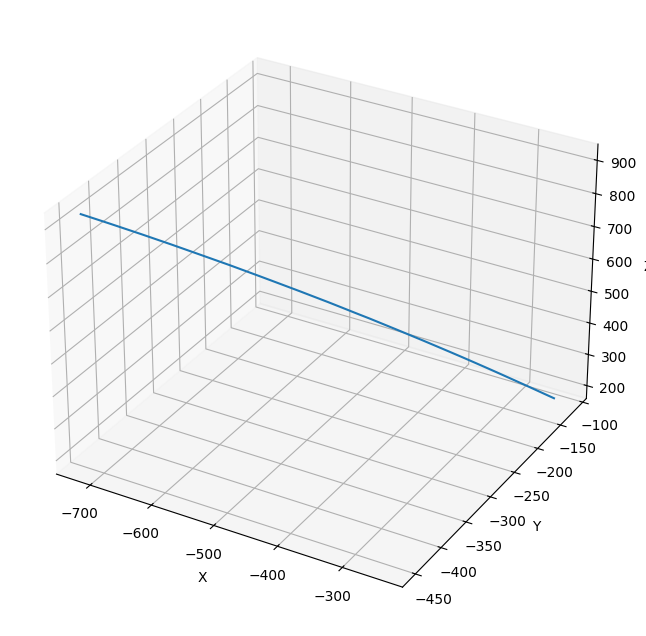

In [136]:


track = df[
    (df["event_id"] == 0) &
    (df["track_id"] == 0)
]

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.plot(
    track["x"],
    track["y"],
    track["z"]
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

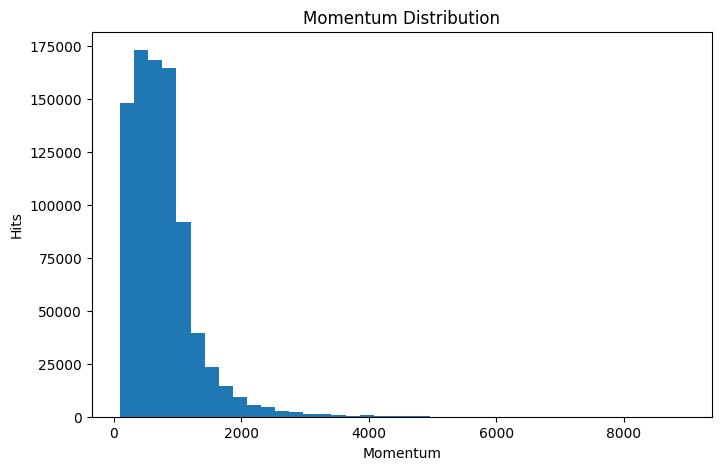

In [137]:
df["momentum"] = np.sqrt(
    df["px"]**2 +
    df["py"]**2 +
    df["pz"]**2
)

plt.figure(figsize=(8,5))

plt.hist(df["momentum"], bins=40)

plt.xlabel("Momentum")
plt.ylabel("Hits")

plt.title("Momentum Distribution")

plt.show()

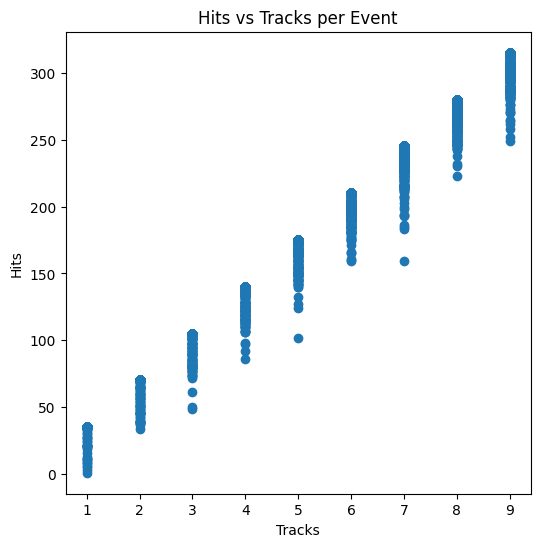

In [138]:
summary = df.groupby("event_id").agg(
    hits=("track_id","size"),
    tracks=("track_id","nunique")
)

plt.figure(figsize=(6,6))

plt.scatter(summary["tracks"], summary["hits"])

plt.xlabel("Tracks")
plt.ylabel("Hits")

plt.title("Hits vs Tracks per Event")

plt.show()

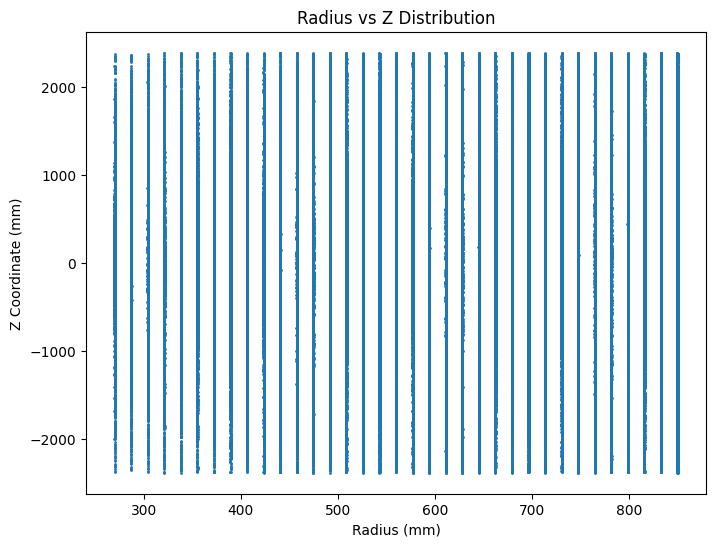

In [139]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["radius"],
    df["z"],
    s=1
)

plt.title("Radius vs Z Distribution")
plt.xlabel("Radius (mm)")
plt.ylabel("Z Coordinate (mm)")

plt.show()

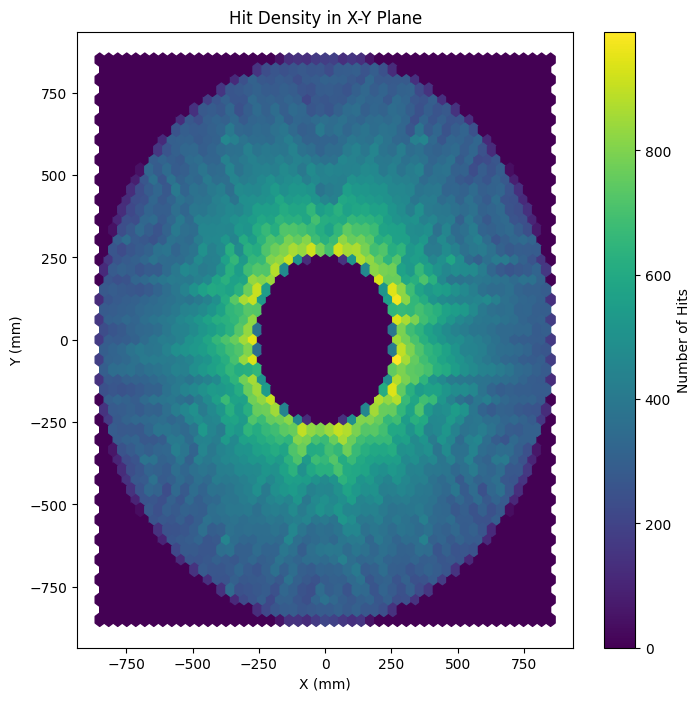

In [140]:
plt.figure(figsize=(8,8))

plt.hexbin(
    df["x"],
    df["y"],
    gridsize=50,
    cmap="viridis"
)

plt.colorbar(label="Number of Hits")

plt.title("Hit Density in X-Y Plane")

plt.xlabel("X (mm)")

plt.ylabel("Y (mm)")

plt.show()

In [141]:
df["phi_hit"] = np.arctan2(
    df["y"],
    df["x"]
)

df["rho_z"] = np.sqrt(
    df["radius"]**2 +
    df["z"]**2
)

print(df["phi_hit"].describe())
print(df["rho_z"].describe())

count    853413.000000
mean          0.004502
std           1.806868
min          -3.141588
25%          -1.539796
50%           0.002603
75%           1.562287
max           3.141586
Name: phi_hit, dtype: float64
count    853413.000000
mean        781.019693
std         377.546778
min         269.809376
25%         520.596846
50%         710.667334
75%         910.194975
max        2532.321866
Name: rho_z, dtype: float64


In [142]:
df["momentum"] = np.sqrt(
    df["px"]**2 +
    df["py"]**2 +
    df["pz"]**2
)
print(df["momentum"].describe())

count    853413.000000
mean        759.879393
std         518.638668
min         100.129986
25%         404.012067
50%         681.612446
75%         965.896863
max        8944.181256
Name: momentum, dtype: float64


In [143]:
print(df["pt"].head())

0    595.070398
1    595.070398
2    595.070398
3    595.070398
4    595.070398
Name: pt, dtype: float64


<Axes: >

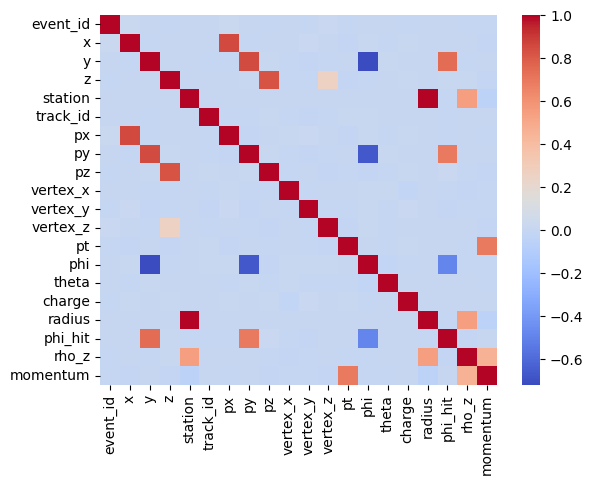

In [144]:
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)


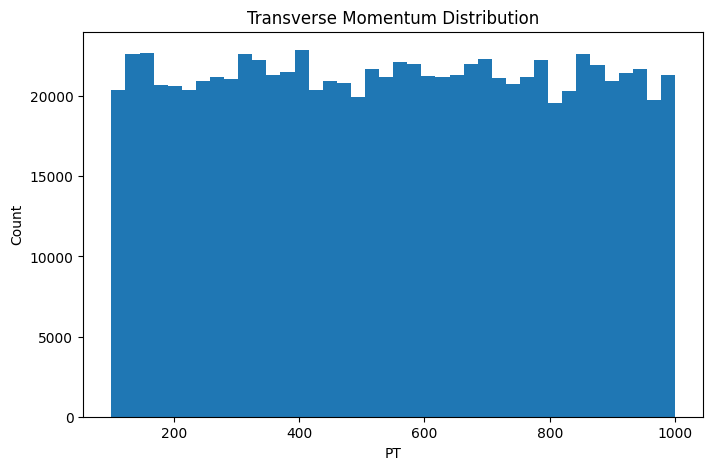

In [145]:
plt.figure(figsize=(8,5))

plt.hist(df["pt"], bins=40)

plt.title("Transverse Momentum Distribution")
plt.xlabel("PT")
plt.ylabel("Count")

plt.show()

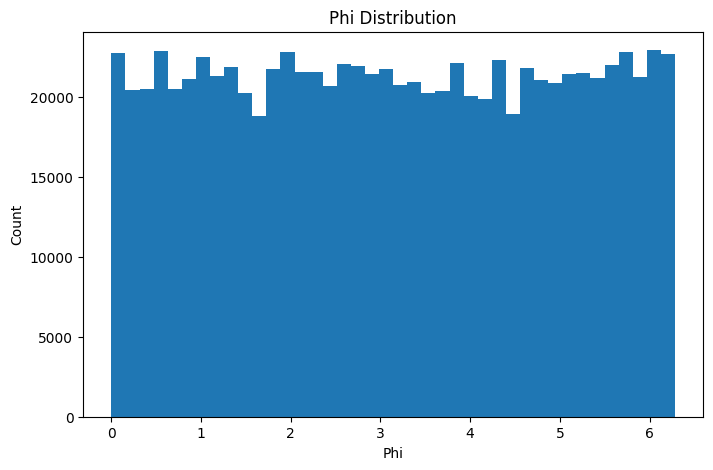

In [146]:
plt.figure(figsize=(8,5))

plt.hist(df["phi"], bins=40)

plt.title("Phi Distribution")
plt.xlabel("Phi")
plt.ylabel("Count")

plt.show()

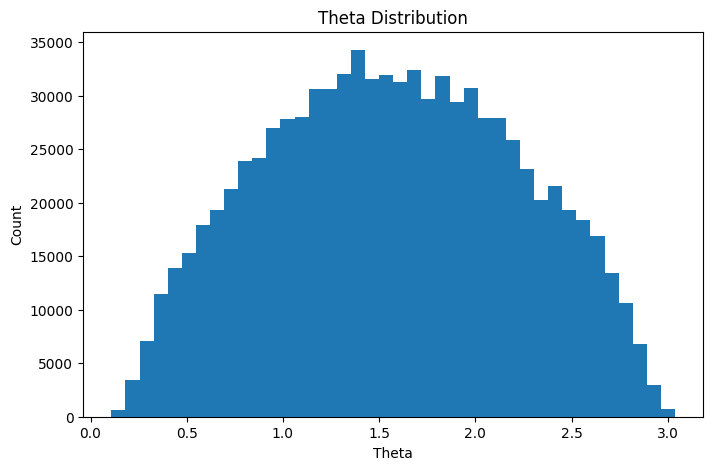

In [148]:
plt.figure(figsize=(8,5))

plt.hist(df["theta"], bins=40)

plt.title("Theta Distribution")
plt.xlabel("Theta")
plt.ylabel("Count")

plt.show()

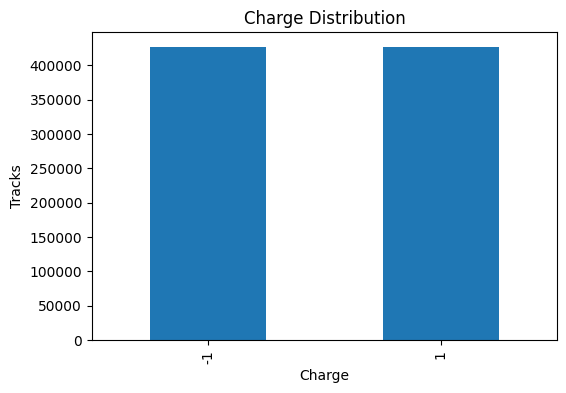

In [149]:
plt.figure(figsize=(6,4))

df["charge"].value_counts().sort_index().plot(kind="bar")

plt.title("Charge Distribution")
plt.xlabel("Charge")
plt.ylabel("Tracks")

plt.show()

In [150]:
df.to_csv(
    "processed_signal_hits.tsv",
    sep="\t",
    index=False
)